# Imports

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Partie 1: Frozen Lake

Nous allons commencer notre TP avec un environnement type grille: le [Frozen Lake](https://gymnasium.farama.org/environments/toy_text/frozen_lake). Cela vous aidera également à vous familiariser avec l'API Gym, largement utilisée dans le monde du RL.

Commencez par lire la [documentation](https://gymnasium.farama.org/environments/toy_text/frozen_lake) de l'environnement Frozen Lake.

## Print utils

In [2]:
def int_action_to_str(int_action):
    if int_action == 0:
        return "left"
    if int_action == 1:
        return "down"
    if int_action == 2:
        return "right"
    else:
        return "up"

for i in range(4):
    print(f"Corresponding action to {i} : {int_action_to_str(i)}")

Corresponding action to 0 : left
Corresponding action to 1 : down
Corresponding action to 2 : right
Corresponding action to 3 : up


In [3]:
def print_values(values, grid_width):
    for i in range(int(len(values)/grid_width)):
        print(values[i*grid_width:(i+1)*grid_width])

print(f"Example of printing values in a grid of width 4:")
print_values(np.arange(16), 4)

def print_policy(policy, grid_width):
    for i in range(int(len(policy)/grid_width)):
        print([int_action_to_str(_a) for _a in policy[i*grid_width:(i+1)*grid_width]])

print()
print(f"Example of printing policy in a grid of width 4:")
print_policy(np.arange(16)%4, 4)

Example of printing values in a grid of width 4:
[0 1 2 3]
[4 5 6 7]
[ 8  9 10 11]
[12 13 14 15]

Example of printing policy in a grid of width 4:
['left', 'down', 'right', 'up']
['left', 'down', 'right', 'up']
['left', 'down', 'right', 'up']
['left', 'down', 'right', 'up']


In [4]:
def print_q_values(q_values, grid_width, precision : int = 2):
    for i in range(int(len(q_values)/grid_width)):
        _q_values_to_print = []
        for _q_values in q_values[i*grid_width:(i+1)*grid_width]:
            _q_values_to_print.append({int_action_to_str(_k): round(_v, precision).item() for _k, _v in enumerate(_q_values)})
        print(_q_values_to_print)
        
print(f"Example of printing q_values in a grid of width 4:")
print_q_values(np.random.rand(16, 4), 4)

Example of printing q_values in a grid of width 4:
[{'left': 0.59, 'down': 0.56, 'right': 0.61, 'up': 0.88}, {'left': 0.13, 'down': 0.69, 'right': 0.7, 'up': 0.77}, {'left': 0.93, 'down': 0.92, 'right': 0.75, 'up': 0.76}, {'left': 0.15, 'down': 0.88, 'right': 0.23, 'up': 0.45}]
[{'left': 0.54, 'down': 0.94, 'right': 0.18, 'up': 0.49}, {'left': 0.81, 'down': 0.07, 'right': 0.84, 'up': 0.8}, {'left': 0.36, 'down': 0.46, 'right': 0.74, 'up': 0.55}, {'left': 0.14, 'down': 0.16, 'right': 0.44, 'up': 0.98}]
[{'left': 0.34, 'down': 0.52, 'right': 0.19, 'up': 0.47}, {'left': 0.92, 'down': 0.14, 'right': 0.27, 'up': 0.54}, {'left': 0.12, 'down': 0.27, 'right': 0.67, 'up': 0.79}, {'left': 0.13, 'down': 0.84, 'right': 0.26, 'up': 0.19}]
[{'left': 0.17, 'down': 0.41, 'right': 0.07, 'up': 0.38}, {'left': 0.13, 'down': 0.84, 'right': 0.25, 'up': 0.19}, {'left': 0.25, 'down': 0.86, 'right': 0.75, 'up': 0.69}, {'left': 0.44, 'down': 0.75, 'right': 0.95, 'up': 0.5}]


## A) Version déterministe

Créons une première instance de l'environnement avec une carte spécifique:

In [5]:
env = gym.make(
    'FrozenLake-v1', 
    desc=["SFFF", "FHFH", "FFFH", "HFFG"], 
    is_slippery=False, 
    render_mode="rgb_array",   # "rgb_array" produces RGB frames to plot, "human" opens a window (doesn't work on notebooks)
    )

L'objet `env` est un environnement Gym. Ses méthodes principales sont:
- `obs, info = env.reset()` : réinitialise l'environnement et renvoie l'état initial (observation) et des informations supplémentaires.
- `obs, reward, terminated, truncated, info = env.step(action)` : effectue l'action `action` dans l'environnement et renvoie le nouvel état (observation), la reward, un booléen indiquant si l'épisode est terminé, un booléen indiquant si l'épisode a été tronqué et des informations supplémentaires.
- `img = env.render()` : affiche l'état actuel de l'environnement (utile pour visualiser la grille).

Il est nécessaire de reset l'environnement pour lancer un épisode:

In [6]:
obs, info = env.reset()

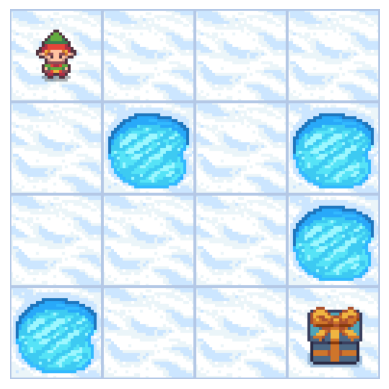

In [7]:
img = env.render()

plt.imshow(img)
plt.axis('off')
plt.show()

Cette classe permet d'agréger les frames des env.render() puis d'afficher l'épisode à la fin.

In [8]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

class EpisodeAnimator:
    def __init__(self, interval: int = 200):
        """
        interval: delay between frames in milliseconds
        """
        self.frames = []
        self.interval = interval
    
    def add_frame(self, frame):
        """Add a single frame (numpy RGB array) to the animation."""
        self.frames.append(frame)
    
    def display_animation(self):
        """Render and display the animation inline in a Jupyter notebook."""
        if not self.frames:
            raise ValueError("No frames to animate. Use add_frame() first.")
        
        fig = plt.figure()
        img = plt.imshow(self.frames[0])
        plt.axis('off')

        def animate(i):
            img.set_data(self.frames[i])
            return [img]
        
        ani = animation.FuncAnimation(
            fig, animate, frames=len(self.frames),
            interval=self.interval, blit=True
        )
        plt.close(fig)  # Prevent static last frame from showing
        return HTML(ani.to_jshtml())

Cette fonction joue (évalue) une certaine politique dans un certain environnement précisés pendant 1 épisode, et retourne les récompenses cumulées ainsi que les frames de l'épisode.

In [9]:
from typing import Callable


def eval_policy_1_episode(env : gym.Env, policy : Callable, do_animation : bool = True):
    observation, info = env.reset()
    done = False
    total_reward = 0
    step = 0
    animator = EpisodeAnimator(interval=int(1000 / env.metadata["render_fps"])) if do_animation else None  # real-time speed

    while not done:

        if do_animation:
            animator.add_frame(env.render())

        action = policy(observation)
        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
        step += 1

    if do_animation:
        animator.add_frame(env.render()) # add last frame
        animation = animator.display_animation()
    else:
        animation = None

    return {"total_reward": total_reward, "steps": step, "animation" : animation}

Codez désormais une stratégie permettant de résoudre le maze:

In [10]:
def policy_hardcoded(observation):
    # Implement a hardcoded policy
    # ---- <your code here> ----
    if observation in [0, 4, 10]:
        action = 1  # down
    else:
        action = 2  # right
    # --------------------------
    return action

result = eval_policy_1_episode(env, policy_hardcoded, do_animation=True)
print(f"Total reward: {result['total_reward']}")
print(f"Total steps: {result['steps']}")
print(f"Animation:")
result['animation']

Total reward: 1
Total steps: 6
Animation:


Testez à nouveau votre stratégie avec cette nouvelle carte. Que fait-elle ?

In [11]:
env = gym.make('FrozenLake-v1', desc=["SHFF", "FHFH", "FFHF", "FFFG"], is_slippery=False, render_mode="rgb_array")

result = eval_policy_1_episode(env, policy_hardcoded, do_animation=True)

print(f"Total reward: {result['total_reward']}")
print(f"Total steps: {result['steps']}")
print(f"Animation:")
result['animation']

Total reward: 0
Total steps: 4
Animation:


## B) Version stochastique

Passons maintenant à une version stochastique où notre agent peut "glisser" perpendiculairement à la direction choisie.

In [12]:
env = gym.make('FrozenLake-v1', desc=["SFFF", "FHFH", "FFFH", "HFFG"], is_slippery=True, render_mode="rgb_array")

In [13]:
result = eval_policy_1_episode(env, policy_hardcoded, do_animation=True)

print(f"Total reward: {result['total_reward']}")
print(f"Total steps: {result['steps']}")
print(f"Animation:")
result['animation']

Total reward: 0
Total steps: 3
Animation:


Essayez maintenant de trouver une stratégie sûre pour la carte suivante:

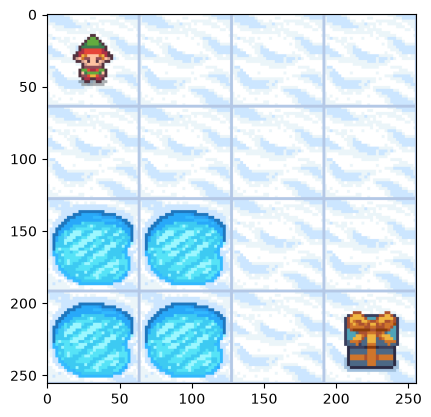

In [14]:
env = gym.make('FrozenLake-v1', desc=["SFFF", "FFFF", "HHFF", "HHFG"], is_slippery=True, render_mode="rgb_array")
obs, info = env.reset()
array = env.render()
plt.imshow(array)

Votre stratégie sera testée plusieurs fois pour s'assurer de sa fiabilité.

In [15]:
def eval_policy_n_episodes(env, policy, n=5, do_animation=True):
    """Evaluate a policy over multiple episodes.

    Args:
        env (gym.Env): The environment to evaluate the policy on.
        policy (Callable): the policy to evaluate : policy(observation) -> action
        n (int, optional): The number of episodes to evaluate the policy on. Defaults to 5.
        do_animation (bool, optional): Whether to render the environment during evaluation. Only the last episode is rendered. Defaults to True.

    Returns:
        dict: A dictionary containing the evaluation results.
    """
    results = {}
    for i in tqdm(range(n)):
        result_episode = eval_policy_1_episode(env, policy, do_animation=do_animation and i == n-1)
        for key, value in result_episode.items():
            if key not in results:
                results[key] = []
            results[key].append(value)
    return results


In [16]:
env = gym.make('FrozenLake-v1', desc=["SFFF", "FFFF", "HHFF", "HHFG"], is_slippery=True, render_mode="rgb_array")

def policy_hardcoded_2(observation):
    # ---- <your code here> ----
    # When slipping, the agent moves perpendicularly to the chosen direction, never backwards.
    # We therefore choose, in each column, a direction whose perpendicular moves can never lead to a hole.
    column = observation % 4
    if column <= 1:
        action = 3  # up: can only slip left or right, never down into the holes
    elif column == 2:
        action = 2  # right: can only slip up or down, never left into the holes
    else:
        action = 1  # down: can only slip left (column 2 is safe) or right (wall)
    # --------------------------
    return action

results = eval_policy_n_episodes(env, policy_hardcoded_2, n=10, do_animation=True)

print(f"Total reward: {results['total_reward']}")
print(f"Total steps: {results['steps']}")
print(f"Animation (last episode):")
results['animation'][-1]

100%|██████████| 10/10 [00:00<00:00, 23.67it/s]

Total reward: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Total steps: [16, 15, 12, 30, 29, 9, 21, 20, 19, 15]
Animation (last episode):


# Partie 2: Q-Learning

## Framework for Reinforcement Learning Agents


Pour faire les choses proprement nous allons définir une classe de base pour les agents de RL.
Cette classe définit une interface python à respecter pour tout agent de RL. Les méthodes suivantes doivent être implémentées :

- `__init__(self, env: gym.Env, **kwargs)`: Le constructeur prend un environnement Gymnasium comme entrée (et d'autres paramètres dépendant de l'agent si besoin)
- `action = act(self, obs)`: Cette méthode doit retourner l'action à entreprendre en fonction de l'observation de l'état actuel.
- `learn(self, obs, action, reward, next_obs, terminated, truncated)`: Cette méthode doit mettre à jour la politique de l'agent en fonction de l'expérience acquise sur la dernière transition. Comme dans `env.step()`, il y a deux façons pour un épisode de s'arrêter :
    - `terminated` : l'épisode s'est terminé dans un état terminal (trou, objectif atteint...). Il n'y a plus de récompense future après `next_obs`.
    - `truncated` : l'épisode a été coupé par une limite de temps. `next_obs` n'est **pas** un état terminal : l'agent aurait pu continuer à recevoir des récompenses.


In [17]:
class AgentRL:

    def __init__(self, env : gym.Env):
        self.env = env

    def act(self, obs):
        raise NotImplementedError()

    def learn(self, obs, action, reward, next_obs, terminated, truncated):
        raise NotImplementedError()

Un exemple d'agent (aléatoire) respectant ce framework :

In [18]:
class RandomAgent(AgentRL):

    def act(self, obs):
        return self.env.action_space.sample()

    def learn(self, obs, action, reward, next_obs, terminated, truncated):
        pass  # do nothing

Un autre exemple d'agent basé sur une fonction politique spécifiée :

In [19]:
class HardcodedAgent(AgentRL):

    def __init__(self, env : gym.Env, policy : Callable):
        super().__init__(env)
        self.policy = policy

    def act(self, obs):
        return self.policy(obs)

    def learn(self, obs, action, reward, next_obs, terminated, truncated):
        pass  # do nothing

Une fois votre agent implémenté, ces deux fonctions serviront respectivement à l'entraîner et à l'évaluer.

In [20]:
def train_agent_n_episodes(env : gym.Env, agent : AgentRL, n : int = 20, verbose_freq : int = None) -> dict:
    """Train the agent for a number of episodes.

    Args:
        env (gym.Env): The environment to train the agent in.
        agent (AgentRL): The agent to train.
        n (int, optional): The number of episodes to train the agent for. Defaults to 20.
        verbose_freq (int, optional): Episode frequency to print progress. If None, no progress is printed. Defaults to None.

    Returns:
        dict: A dictionary containing the total rewards and steps taken in each episode.
    """
    results = {
        "total_rewards": [],
        "steps": [],
    }

    # Training loop
    for episode in tqdm(range(n)):
        observation, info = env.reset()
        total_reward = 0
        step = 0
        done = False
        while not done:
            action = agent.act(observation)
            next_observation, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward
            agent.learn(observation, action, reward, next_observation, terminated, truncated)
            step += 1
            observation = next_observation

        # Log results
        results["total_rewards"].append(total_reward)
        results["steps"].append(step)
        if verbose_freq is not None and (episode + 1) % verbose_freq == 0:
            avg_reward = np.mean(results["total_rewards"][-verbose_freq:])
            avg_steps = np.mean(results["steps"][-verbose_freq:])
            print(f"Episode {episode + 1}/{n} - Average Reward: {avg_reward:.2f}, Average Steps: {avg_steps:.2f}")

    return results

def eval_agent_n_episodes(env : gym.Env, agent : AgentRL, n : int = 5, do_animation : bool = True) -> dict:
    return eval_policy_n_episodes(env, agent.act, n=n, do_animation=do_animation)

Pour commencer, nous utiliserons cet environnement très simple et sans trous.

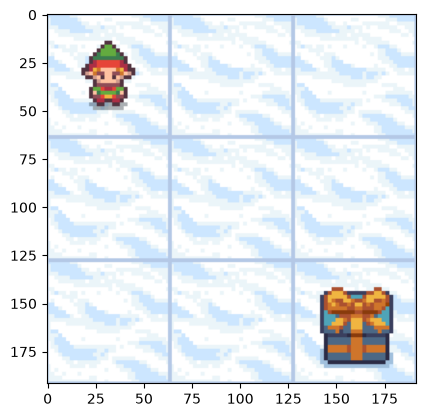

In [21]:
env = gym.make('FrozenLake-v1', desc=["SFF", "FFF", "FFG"], is_slippery=False, render_mode="rgb_array")
obs, info = env.reset()
plt.imshow(env.render())

## A) Q-Learning

Implémentez à présent votre premier algorithme : le Q-Learning.

Rappel : l'algorithme de Q-Learning garde en mémoire une table de Q-values estimées $\hat{Q}$ qui à chaque couple d'état action $(s,a)$ associe une valeur $\hat{Q}(s,a)$ représentant une estimation de la valeur future de l'état $s$ après avoir effectué l'action $a$. Il met à jour cette table en utilisant la formule suivante :

$$\hat{Q}(s,a) \leftarrow \hat{Q}(s,a) + \alpha \left( r + \gamma \max_{a'} \hat{Q}(s',a') - \hat{Q}(s,a) \right)$$

où :
- $\alpha$ est le taux d'apprentissage,
- $r$ est la récompense reçue après avoir effectué l'action $a$ dans l'état $s$,
- $s'$ est l'état résultant de l'action $a$,
- $\gamma$ est le discount factor.

Note : si $s'$ est un état terminal (indiqué par la variable `terminated`), la valeur de $\hat{Q}(s',a')$ est nulle car il n'y a pas d'état suivant. Une formule plus correcte pour la mise à jour dans ce cas est :

$$\hat{Q}(s,a) \leftarrow \hat{Q}(s,a) + \alpha \left( r - \hat{Q}(s,a) \right)$$

Attention : si l'épisode est seulement tronqué (`truncated`), $s'$ n'est pas terminal et on utilise la formule normale.

### Conseils :

- Vous aurez besoin de maintenir une table de Q-values $\hat{Q}$ pour chaque paire d'état-action $(s,a)$, initialisées arbitrairement.
- N'oubliez pas la notion d'exploration : vous devez parfois choisir une action aléatoire plutôt que celle qui maximise la Q-value estimée, afin d'explorer de nouvelles régions de l'espace d'état/actions.
- En cas d'égalité entre Q-values, choisissez une action au hasard parmi les meilleures (`np.argmax` renvoie toujours la première).
- Le nombre d'actions et d'états existants est accessible par `env.action_space.n` et `env.observation_space.n`.
- À vous de trouver de bonnes valeurs d'hyperparamètres (pour $\alpha$, $\gamma$, et $\epsilon$).


In [22]:
class QLearningAgent(AgentRL):

    def __init__(
        self,
        env : gym.Env,
        alpha : float,
        gamma : float,
        epsilon : float,
        ):
        super().__init__(env)
        # ---- <your code here> ----
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = np.zeros((env.observation_space.n, env.action_space.n))
        # --------------------------

    def act(self, obs):
        # ---- <your code here> ----
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.env.action_space.n)
        return np.random.choice(np.flatnonzero(self.q_table[obs] == self.q_table[obs].max()))  # random tie-breaking
        # --------------------------

    def learn(self, obs, action, reward, next_obs, terminated, truncated):
        # ---- <your code here> ----
        if terminated:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.q_table[next_obs])
        self.q_table[obs, action] += self.alpha * (target - self.q_table[obs, action])
        # --------------------------

agent = QLearningAgent(
    env = env,
    # ---- <your code here> ----
    alpha = 0.1,
    gamma = 0.99,
    epsilon = 0.1,
    # --------------------------
)



# Train for 2 episodes here to debug
train_results = train_agent_n_episodes(
    env = env,
    agent = agent,
    n = 2,
)
print(train_results)

100%|██████████| 2/2 [00:00<00:00, 1461.94it/s]

{'total_rewards': [1, 1], 'steps': [40, 20]}


Entrainez ensuite votre agent Q-Learning sur l'environnement.

In [23]:
train_results = train_agent_n_episodes(
    env = env,
    agent = agent,
    n = 200,
)

100%|██████████| 200/200 [00:00<00:00, 7790.89it/s]


Après entrainement, vous pouvez afficher les courbes d'apprentissage depuis `train_results`.

In [24]:
import matplotlib.pyplot as plt

def plot_results(results: dict):
    """
    Plots each metric in results on a separate subplot.
    Example results:
        {
            'total_rewards': [0.0, 1.0, 0.0],
            'steps': [100, 95, 100]
        }
    """
    n_metrics = len(results)
    fig, axes = plt.subplots(n_metrics, 1, figsize=(10, 4 * n_metrics), sharex=True)

    if n_metrics == 1:
        axes = [axes]  # Make iterable if only one metric

    for ax, (key, values) in zip(axes, results.items()):
        ax.plot(values, label=key)
        ax.set_title(key.replace("_", " ").title())
        ax.set_ylabel("Value")
        ax.grid(True)
        ax.legend()

    axes[-1].set_xlabel("Episode")
    plt.tight_layout()
    plt.show()


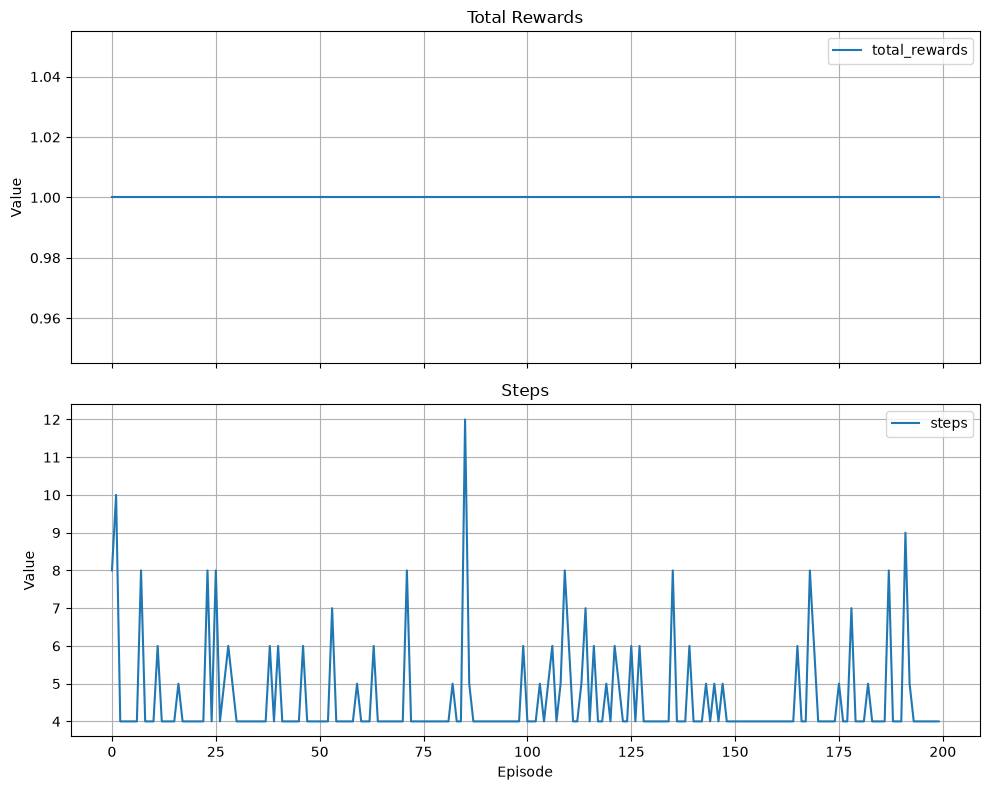

In [25]:
plot_results(train_results)

Evaluons à présent notre agent.

Remarque (facultatif) : il pourrait être pertinent de passer l'agent en mode évaluation lorsqu'il n'est pas en cours d'entraînement. Ici cela correspondrait à désactiver l'exploration (c'est-à-dire, utiliser une politique déterministe).

In [26]:
eval_results = eval_agent_n_episodes(
    env = env,
    agent = agent,
    n = 10,
    )

print(f"Total reward: {eval_results['total_reward']}, mean = {np.mean(eval_results['total_reward'])}")
print(f"Total steps: {eval_results['steps']}, mean = {np.mean(eval_results['steps'])}")
print(f"Animation (last episode):")
eval_results['animation'][-1]

100%|██████████| 10/10 [00:00<00:00, 87.74it/s]

Total reward: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], mean = 1.0
Total steps: [4, 4, 4, 4, 4, 4, 6, 4, 4, 4], mean = 4.2
Animation (last episode):


## B) SARSA

Implémentons à présent SARSA, dont la formule d'apprentissage est : $Q(s, a) \leftarrow Q(s, a) + \alpha \left( r + \gamma Q(s', a') - Q(s, a) \right)$

Vous aurez donc à prendre $a' = \pi(s')$ dans votre code, plutôt que de prendre le maximum de $Q(s', \cdot)$. Attention : $a'$ doit être l'action qui sera **réellement jouée** à l'étape suivante, d'où l'attribut `next_action` ci-dessous.

100%|██████████| 200/200 [00:00<00:00, 14740.65it/s]


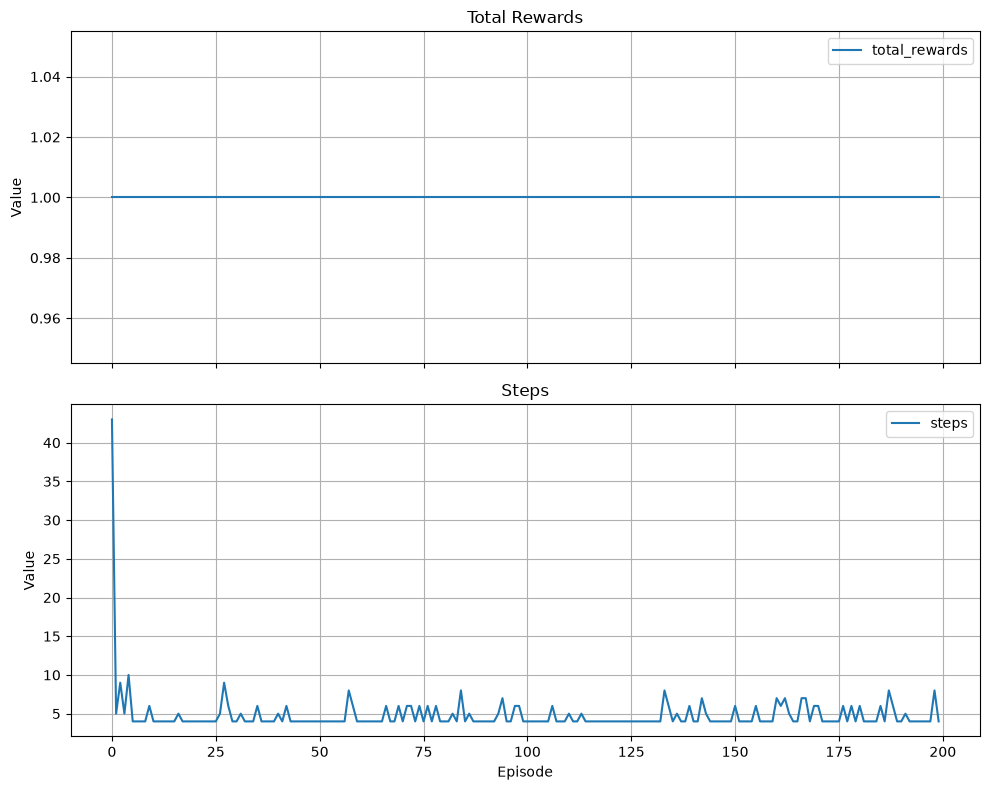

100%|██████████| 10/10 [00:00<00:00, 84.67it/s]

Total reward: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], mean = 1.0
Total steps: [4, 6, 4, 4, 4, 4, 4, 4, 4, 4], mean = 4.2
Animation (last episode):


In [27]:
# Define environment
env = gym.make('FrozenLake-v1', desc=["SFF", "FFF", "FFG"], is_slippery=False, render_mode="rgb_array")

# Define agent
class SARSA_Agent(AgentRL):

    def __init__(
        self,
        env : gym.Env,
        alpha : float,
        gamma : float,
        epsilon : float,
        ):

        super().__init__(env)
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = np.zeros((env.observation_space.n, env.action_space.n))
        self.next_action = None  # a' chosen during the last update, to be played at the next step

    def epsilon_greedy(self, obs):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.env.action_space.n)
        # break ties randomly: np.argmax always returns the first maximum (here "left")
        return np.random.choice(np.flatnonzero(self.q_table[obs] == self.q_table[obs].max()))

    def act(self, obs):
        if self.next_action is not None:
            action, self.next_action = self.next_action, None
            return action
        return self.epsilon_greedy(obs)

    def learn(self, obs, action, reward, next_obs, terminated, truncated):
        if terminated:
            target = reward
        else:
            next_action = self.epsilon_greedy(next_obs)
            target = reward + self.gamma * self.q_table[next_obs, next_action]
            if not truncated:
                self.next_action = next_action
        self.q_table[obs, action] += self.alpha * (target - self.q_table[obs, action])

agent = SARSA_Agent(
    env=env,
    alpha=0.1,
    gamma=0.9,
    epsilon=0.1
)

# Train the agent
training_results = train_agent_n_episodes(env, agent, n=200)

# Plot training curves
plot_results(training_results)

# Evaluate the agent
eval_results = eval_agent_n_episodes(env, agent, n=10)

print(f"Total reward: {eval_results['total_reward']}, mean = {np.mean(eval_results['total_reward'])}")
print(f"Total steps: {eval_results['steps']}, mean = {np.mean(eval_results['steps'])}")
print(f"Animation (last episode):")
eval_results['animation'][-1]

## C) Environnement plus difficile

Entrainons nos agents Q-Learning et SARSA dans l'environnement "The Cliff" du cours. 

Cet environnement est en l'état assez difficile parce que le signal de récompense est très sparse. L'agent ne devrait pas réussir normalement.

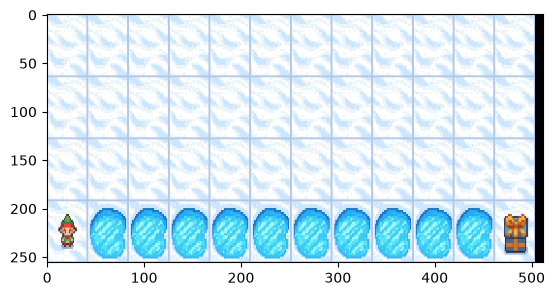

In [28]:
env = gym.make('FrozenLake-v1', desc=["FFFFFFFFFFFF", "FFFFFFFFFFFF", "FFFFFFFFFFFF", "SHHHHHHHHHHG"], is_slippery=False, render_mode="rgb_array")
obs, info = env.reset()
img = env.render()
plt.imshow(img)

100%|██████████| 1000/1000 [00:00<00:00, 6712.00it/s]


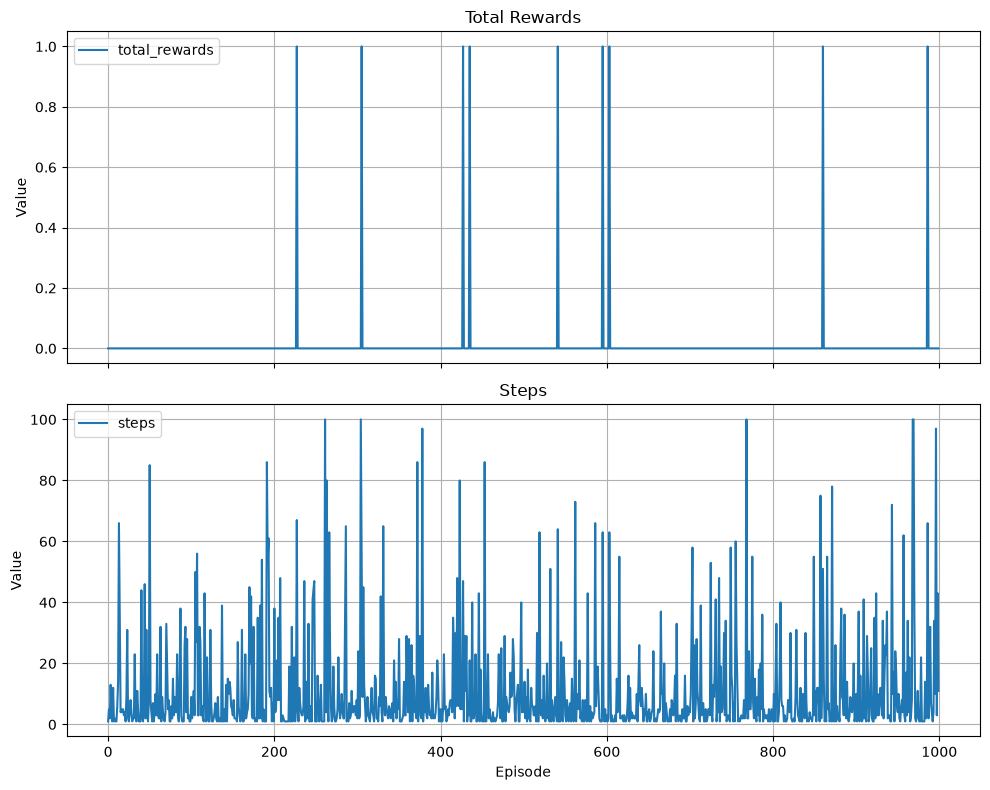

100%|██████████| 10/10 [00:00<00:00, 19.74it/s]

Total reward: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], mean = 0.0
Total steps: [70, 2, 3, 4, 8, 1, 7, 30, 4, 14], mean = 14.3
Animation (last episode):


In [29]:
agent = QLearningAgent(env, alpha=0.8, gamma=0.99, epsilon=0.33)

# Train the agent
training_results = train_agent_n_episodes(env, agent, n=1000)

# Plot training curves
plot_results(training_results)

# Evaluate the agent
eval_results = eval_agent_n_episodes(env, agent , n=10)
print(f"Total reward: {eval_results['total_reward']}, mean = {np.mean(eval_results['total_reward'])}")
print(f"Total steps: {eval_results['steps']}, mean = {np.mean(eval_results['steps'])}")
print(f"Animation (last episode):")
eval_results['animation'][-1]

Comment rendre cet environnement plus facile à apprendre pour notre agent ? Le problème est que l'agent doit explorer beaucoup avant de tomber sur un signal de reward (lorsqu'il arrive au coffre). Toutes les autres trajectoires offrent une récompense totale nulle, et l'agent va en pratique très souvent tomber dans les trous (qui terminent l'épisode avec une reward nulle) et est donc bloqué.

Les solutions proposées sont les suivantes :
- 1) Rendre les trous punitifs, pour cela on peut utiliser un "wrapper" d'environnement. Les wrappers sont des classes qui modifient le comportement d'un environnement Gym sans en changer le code source. Dans notre cas, on peut penser à donner une récompense négative lorsque l'épisode s'arrête (`terminated` ou `truncated`) sans avoir trouvé le coffre (`reward` < 1). Vous pouvez vous inspirer du code suivant (double click sur cette cellule pour copier le code) :

```python
class PunishTerminationWrapper(gym.Wrapper):
    """
    Punishes any termination that doesn't give +1 reward with -1.
    """
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        # ---- <your code here> ----

        # --------------------------

        return obs, reward, terminated, truncated, info

env = PunishTerminationWrapper(env)
```

- 2) Utiliser la politique d'exploration UCB (Upper-Confidence Bound) plutôt que epsilon-greedy. Cette politique est fondamentalement curieuse envers les couples (états, actions) qu'elle n'a jamais vus, et peut donc explorer la totalité de notre environnement beaucoup plus rapidement. Notez que la politique UCB est très efficace mais n'est pas applicable lorsque l'espace des états ou des actions est non discret. Pour rappel, la formule de la politique UCB est la suivante : $UCB(s, a) = Q(s, a) + c \sqrt{\frac{\ln N(s)}{N(s, a)}}$ avec $N()$ dénotant le nombre de fois qu'un état ou qu'un couple (état, action) a été visité. Attention : le bonus d'exploration est local à chaque état, l'agent a donc besoin de nombreux épisodes pour atteindre le bout de la falaise : prévoyez environ 3000 épisodes d'entraînement.

- 3) Une méthode incitant l'exploration est l'Initialisation Optimiste. Cette méthode consiste à initialiser les valeurs de la fonction de valeur (ou Q-Values) à des valeurs optimistes. Les politiques qui se basent sur la Q-Value vont ainsi explorer davantage les actions qui n'ont pas encore été essayées, car elles commenceront avec une valeur Q élevée, puis celle-ci sera ajustée à la baisse au fur et à mesure de l'apprentissage, ce qui incite l'agent à passer à d'autres actions.

Vous pouvez implémenter une ou plusieurs de ces solutions pour améliorer l'apprentissage de vos agents, puis run à nouveau la cellule précédente.


### Solution 1 : rendre les trous punitifs avec un wrapper d'environnement

Il faut aussi punir les épisodes tronqués (l'agent qui erre jusqu'à la limite de temps). En ne punissant que les trous, l'agent apprend seulement à les éviter : errer sans fin (récompense 0) lui semble alors aussi bon que les actions qu'il n'a pas encore essayées, et il ne trouve jamais le coffre. En punissant aussi la troncature, toutes les actions déjà essayées sans succès finissent avec une Q-value négative, plus faible que celle (nulle) des actions jamais essayées : cela pousse l'agent à explorer.

100%|██████████| 1000/1000 [00:00<00:00, 3301.43it/s]


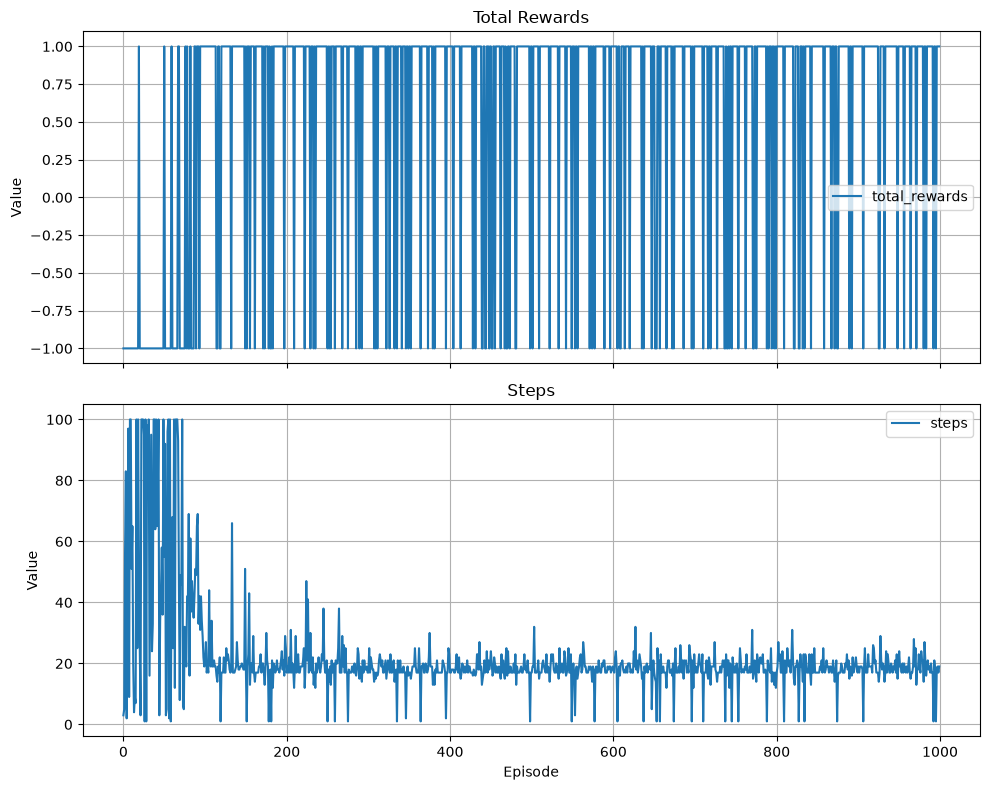

100%|██████████| 10/10 [00:00<00:00, 16.59it/s]

Total reward: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], mean = 1.0
Total steps: [17, 17, 17, 17, 17, 17, 17, 17, 17, 17], mean = 17.0
Animation (last episode):


In [30]:
env = gym.make('FrozenLake-v1', desc=["FFFFFFFFFFFF", "FFFFFFFFFFFF", "FFFFFFFFFFFF", "SHHHHHHHHHHG"], is_slippery=False, render_mode="rgb_array")

class PunishTerminationWrapper(gym.Wrapper):
    """
    Punishes any termination that doesn't give +1 reward with -1.
    """
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        # ---- <your code here> ----
        if (terminated or truncated) and reward < 1:
            reward = -1.0
        # --------------------------

        return obs, reward, terminated, truncated, info

env = PunishTerminationWrapper(env)

agent = QLearningAgent(env, alpha=0.1, gamma=0.9, epsilon=0.1)

# Train the agent
training_results = train_agent_n_episodes(env, agent, n=1000)

# Plot training curves
plot_results(training_results)

# Evaluate the agent greedily (no exploration)
agent.epsilon = 0
eval_results = eval_agent_n_episodes(env, agent, n=10)
print(f"Total reward: {eval_results['total_reward']}, mean = {np.mean(eval_results['total_reward'])}")
print(f"Total steps: {eval_results['steps']}, mean = {np.mean(eval_results['steps'])}")
print(f"Animation (last episode):")
eval_results['animation'][-1]

### Solution 2 : exploration UCB

Le bonus d'exploration est local : dans chaque état, UCB essaie l'action la moins testée. Tant que toutes les Q-values sont nulles, l'agent se comporte donc presque comme une marche aléatoire, et tombe dans un trou bien avant d'atteindre le bout de la falaise. UCB finit par tout explorer, mais il lui faut ici environ 3000 épisodes.

Attention lors de l'évaluation : l'agent n'apprend plus, donc les compteurs $N(s, a)$ ne sont plus mis à jour. Le bonus d'exploration d'une action peu essayée reste alors élevé indéfiniment, et l'agent peut répéter cette action en boucle (par exemple foncer dans un mur). On évalue donc l'agent de manière greedy, avec $c = 0$.

100%|██████████| 3000/3000 [00:00<00:00, 6786.51it/s]


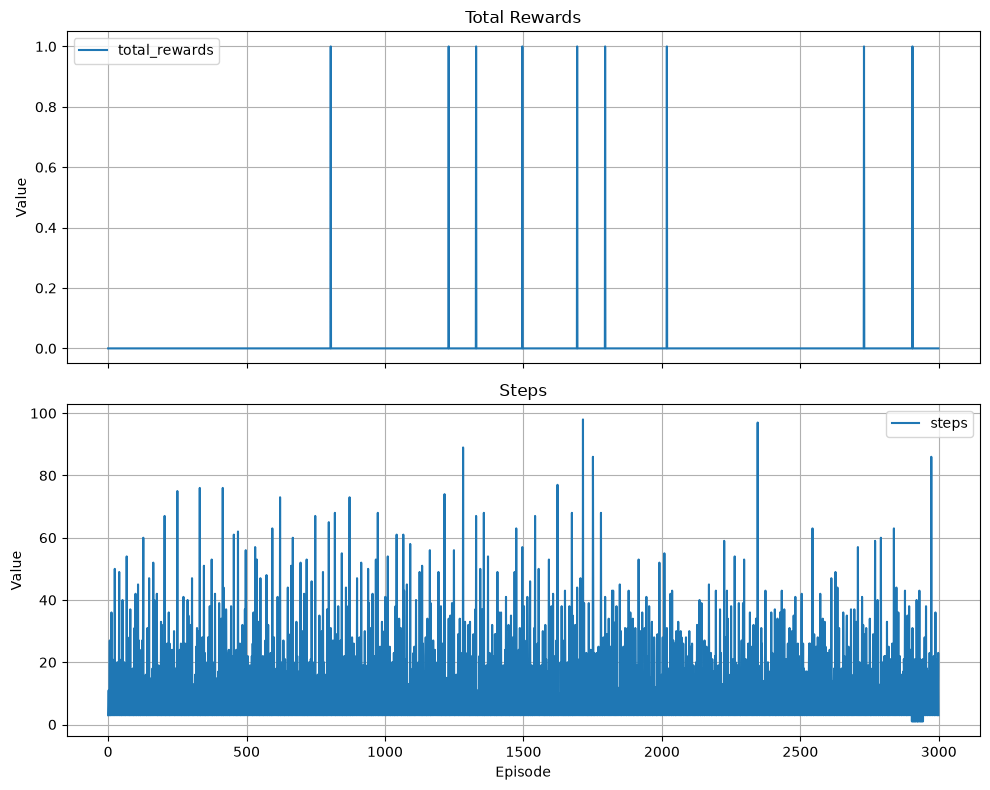

100%|██████████| 10/10 [00:00<00:00, 18.70it/s]

Total reward: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], mean = 1.0
Total steps: [15, 15, 15, 15, 15, 15, 15, 15, 15, 15], mean = 15.0
Animation (last episode):


In [31]:
env = gym.make('FrozenLake-v1', desc=["FFFFFFFFFFFF", "FFFFFFFFFFFF", "FFFFFFFFFFFF", "SHHHHHHHHHHG"], is_slippery=False, render_mode="rgb_array")

class QLearningAgent_UCB(AgentRL):

    def __init__(
        self,
        env : gym.Env,
        alpha : float,
        gamma : float,
        constant_ucb : float,
    ):
        super().__init__(env)
        self.alpha = alpha
        self.gamma = gamma
        self.constant_ucb = constant_ucb
        self.q_table = np.zeros((env.observation_space.n, env.action_space.n))
        self.action_count = np.zeros((env.observation_space.n, env.action_space.n))  # N(s, a)

    def act(self, obs):
        # +1 avoids log(0) and divisions by 0 for actions never tried
        ucb_values = self.q_table[obs] + self.constant_ucb * np.sqrt(np.log(np.sum(self.action_count[obs]) + 1) / (self.action_count[obs] + 1))
        return np.argmax(ucb_values)

    def learn(self, obs, action, reward, next_obs, terminated, truncated):
        if terminated:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.q_table[next_obs])
        self.q_table[obs, action] += self.alpha * (target - self.q_table[obs, action])
        self.action_count[obs, action] += 1

agent = QLearningAgent_UCB(env, alpha=0.1, gamma=0.9, constant_ucb=np.sqrt(2))

# Train the agent
training_results = train_agent_n_episodes(env, agent, n=3000)

# Plot training curves
plot_results(training_results)

# Evaluate the agent greedily (no exploration bonus)
agent.constant_ucb = 0
eval_results = eval_agent_n_episodes(env, agent, n=10)
print(f"Total reward: {eval_results['total_reward']}, mean = {np.mean(eval_results['total_reward'])}")
print(f"Total steps: {eval_results['steps']}, mean = {np.mean(eval_results['steps'])}")
print(f"Animation (last episode):")
eval_results['animation'][-1]

### Solution 3 : initialisation optimiste

Les récompenses étant dans $[0, 1]$, initialiser les Q-values à 1 suffit : toute action non essayée paraît aussi bonne que d'atteindre le coffre.

100%|██████████| 1000/1000 [00:00<00:00, 3579.99it/s]


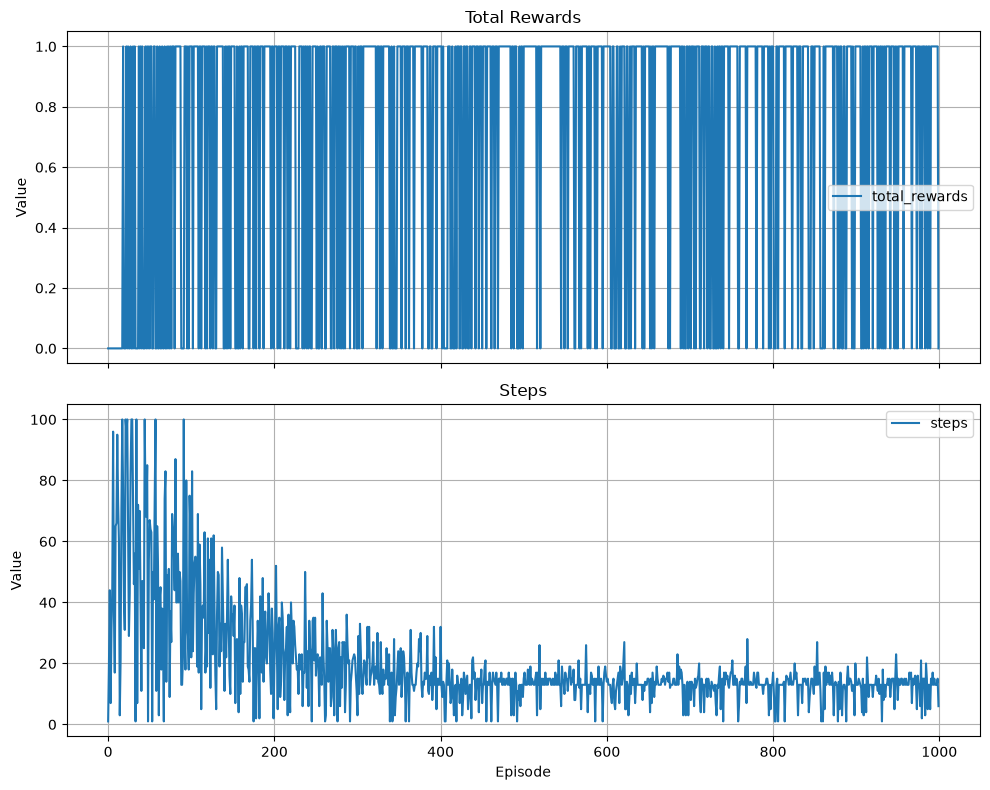

100%|██████████| 10/10 [00:00<00:00, 21.24it/s]

Total reward: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], mean = 1.0
Total steps: [13, 13, 13, 13, 13, 13, 13, 13, 13, 13], mean = 13.0
Animation (last episode):


In [32]:
env = gym.make('FrozenLake-v1', desc=["FFFFFFFFFFFF", "FFFFFFFFFFFF", "FFFFFFFFFFFF", "SHHHHHHHHHHG"], is_slippery=False, render_mode="rgb_array")

agent = QLearningAgent(env, alpha=0.1, gamma=0.9, epsilon=0.1)
agent.q_table += 1  # optimistic initialization

# Train the agent
training_results = train_agent_n_episodes(env, agent, n=1000)

# Plot training curves
plot_results(training_results)

# Evaluate the agent greedily (no exploration)
agent.epsilon = 0
eval_results = eval_agent_n_episodes(env, agent, n=10)
print(f"Total reward: {eval_results['total_reward']}, mean = {np.mean(eval_results['total_reward'])}")
print(f"Total steps: {eval_results['steps']}, mean = {np.mean(eval_results['steps'])}")
print(f"Animation (last episode):")
eval_results['animation'][-1]

# Partie 3: Algorithme Deep Q-Network (DQN)

Il est temps de passer à un environnement plus compliqué : [CartPole](https://gymnasium.farama.org/environments/classic_control/cart_pole/). Il s'agit de maintenir un bâton en équilibre sur un chariot en poussant ce dernier vers la gauche ou vers la droite.

- **Observation** : un vecteur de 4 nombres réels (position du chariot, vitesse du chariot, angle du bâton, vitesse angulaire du bâton).
- **Actions** : 0 (pousser à gauche) ou 1 (pousser à droite).
- **Récompense** : +1 à chaque pas de temps où le bâton tient debout. L'épisode se termine (`terminated`) lorsque le bâton tombe (angle > 12°) ou que le chariot sort de l'écran, et il est tronqué (`truncated`) après 200 pas : le score maximal est donc 200.

L'espace d'observation est continu : on ne peut plus utiliser une table de Q-values. L'apprentissage de la Q-Value passera donc par un réseau de neurones.


Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Observation: [-0.04834799  0.00917354  0.01492701 -0.03631197]


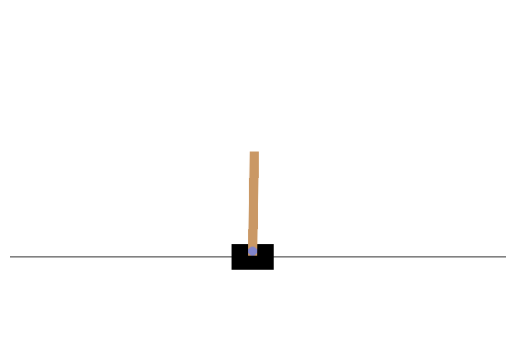

In [33]:
env_cartpole = gym.make("CartPole-v1", max_episode_steps=200, render_mode="rgb_array")
print("Observation space:", env_cartpole.observation_space)
print("Action space:", env_cartpole.action_space)
obs, info = env_cartpole.reset()
print("Observation:", obs)
plt.imshow(env_cartpole.render())
plt.axis('off')
plt.show()

## A) Agent aléatoire

Pour avoir un point de comparaison, regardons les performances d'un agent aléatoire :

In [34]:
# Trying a random agent in CartPole
agent = RandomAgent(env_cartpole)

# Evaluate the agent
eval_results = eval_agent_n_episodes(env_cartpole, agent, n=10)
print(f"Total reward: {eval_results['total_reward']}, mean = {np.mean(eval_results['total_reward'])}")
print(f"Total steps: {eval_results['steps']}, mean = {np.mean(eval_results['steps'])}")
print(f"Animation (last episode):")
eval_results['animation'][-1]

100%|██████████| 10/10 [00:00<00:00, 24.31it/s]

Total reward: [16.0, 22.0, 33.0, 45.0, 27.0, 21.0, 10.0, 14.0, 18.0, 22.0], mean = 22.8
Total steps: [16, 22, 33, 45, 27, 21, 10, 14, 18, 22], mean = 22.8
Animation (last episode):


## B) Replay Buffer

Comme dit dans le cours, plutôt que d'apprendre totalement "online" (c'est-à-dire en utilisant la dernière transition collectée pour faire une mise à jour de la Q-Value), nous allons stocker les transitions dans un buffer, et faire des mises à jour en samplant aléatoirement des transitions dans ce buffer.

Implémentons notre replay buffer permettant de récolter et de sampler aléatoirement des transitions collectées.

In [35]:
import random
import torch
import numpy as np

class ReplayBuffer:
    def __init__(self, capacity, device):
        self.capacity = capacity # capacity of the buffer
        self.data = []
        self.index = 0 # index of the next cell to be filled
        self.device = device
    def append(self, obs, action, reward, next_obs, terminated):
        if len(self.data) < self.capacity:
            self.data.append(None)
        self.data[self.index] = (obs, action, reward, next_obs, terminated)
        self.index = (self.index + 1) % self.capacity
    def sample(self, batch_size):
        batch = random.sample(self.data, batch_size)
        return list(map(lambda x:torch.Tensor(np.array(x)).to(self.device), list(zip(*batch))))
    def __len__(self):
        return len(self.data)

## C) Réseau de neurones pour la Q-Value

L'observation n'étant qu'un vecteur de 4 nombres, un petit réseau de neurones entièrement connecté (MLP) à 2 couches cachées suffit pour approximer la Q-Value. Il prend en entrée l'observation et renvoie une Q-value par action.


In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class QNetwork(nn.Module):
    def __init__(self, obs_dim=4, n_actions=2, hidden_dim=128):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(obs_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.head = nn.Linear(hidden_dim, n_actions)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.head(x)

À votre tour d'implémenter une fonction calculant les Q-values pour un state et jouant greedy à partir de ces Q-values (i.e. retournant l'index de la plus haute Q-value):

In [37]:
def greedy_action(network, obs):
    device = "cuda" if next(network.parameters()).is_cuda else "cpu"
    with torch.no_grad():
        # ---- <your code here> ----
        obs = torch.Tensor(obs).to(device).unsqueeze(0)  # dim = (1, 4): the network expects a batch
        q_values = network(obs)  # dim = (1, n_actions)
        action = q_values.argmax(dim=1).item()
        # --------------------------
    return action

obs, _ = env_cartpole.reset()
network_q_value = QNetwork()
if torch.cuda.is_available():  # Set the DQN to cuda if possible
    network_q_value = network_q_value.to("cuda")

greedy_action(network_q_value, obs)   # test the function

1

## D) Algorithme DQN

Il est temps d'implémenter l'entraînement de notre DQN.
Nous allons utiliser:
- une exploration epsilon-greedy avec un epsilon qui décroît linéairement
- une phase de warm-up au début (les `warmup_episodes` premiers épisodes) où l'agent joue aléatoirement pour remplir le replay buffer
- un target Q-network pour stabiliser l'entrainement : il s'agit d'une copie du Q-network qui "suit" le Q-network principal plus lentement (par Polyak averaging). Le target Q-network est utilisé pour calculer la target dans la loss de DQN :
$$\text{target} = r + \gamma \max_{a'} Q_{\text{target}}(s', a')$$

(et $\text{target} = r$ si $s'$ est terminal, i.e. `terminated` vaut 1)

$$Q_{\text{target}} \leftarrow \tau Q + (1-\tau) Q_{\text{target}}$$

Avec $\tau \ll 1$.

C'est à vous d'implémenter la méthode `act` et le calcul de la loss (MSE entre Q-values courantes et targets) à partir des batchs de transitions samplées dans le replay buffer.

In [38]:
from copy import deepcopy


class DQNAgent(AgentRL):

    def __init__(
        self,
        env : gym.Env,
        network_q_value : nn.Module,
        replay_buffer : ReplayBuffer,
        batch_size : int,
        learning_rate : float,
        gamma : float,
        epsilon_start : float,
        epsilon_end : float,
        epsilon_decay_per_episode : int,
        warmup_episodes : int = 10,
        update_target_tau : float = 0.005,
        device : str = "cpu",
    ):
        super().__init__(env)

        # Hyperparameters
        self.batch_size = batch_size   # batch size for sampling from the replay buffer and do a gradient step
        self.gamma = gamma
        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay_per_episode  # how much to subtract from epsilon per episode
        self.gradient_step_freq = 1  # do a gradient step every gradient_step_freq steps
        self.learning_rate = learning_rate
        self.warmup_episodes = warmup_episodes # number of episodes to fill the replay buffer before starting training
        self.update_target_tau = update_target_tau  # target network update rate (Polyak averaging)

        # Internal variables
        self.network_q_value = network_q_value.to(device)
        self.network_q_value_target = deepcopy(self.network_q_value).to(device)
        self.replay_buffer = replay_buffer
        self.optimizer = torch.optim.Adam(self.network_q_value.parameters(), lr=self.learning_rate)
        self.device = device
        self.training_steps = 0  # number of training steps done so far
        self.training_episodes = 0  # number of training episodes done so far
        self.epsilon = epsilon_start

    def act(self, obs):
        # ---- <your code here> ----
        if self.training_episodes < self.warmup_episodes or np.random.rand() < self.epsilon:
            action = self.env.action_space.sample()
        else:
            action = greedy_action(self.network_q_value, obs)
        # --------------------------
        return action

    def learn(self, obs, action, reward, next_obs, terminated, truncated):

        # Store the transition in the replay buffer
        self.replay_buffer.append(obs, action, reward, next_obs, terminated)
        self.training_steps += 1

        # Linearly decay epsilon
        if terminated or truncated:
            self.training_episodes += 1
            self.epsilon -= self.epsilon_decay
            self.epsilon = max(self.epsilon, self.epsilon_end)

        # Skip if not enough samples in the replay buffer or not time for a gradient step
        if len(self.replay_buffer) < self.batch_size or self.training_steps % self.gradient_step_freq != 0:
            return

        # Sample a batch of transitions from the replay buffer and do some conversions
        obs_batch, action_batch, reward_batch, next_obs_batch, terminated_batch = self.replay_buffer.sample(self.batch_size)
        # obs_batch and next_obs_batch: dim = (batch_size, 4)
        action_batch = action_batch.long().unsqueeze(1) # dim = (batch_size, 1)
        reward_batch = reward_batch.unsqueeze(1)  # dim = (batch_size, 1)
        terminated_batch = terminated_batch.unsqueeze(1)  # dim = (batch_size, 1)

        # Compute current Q values
        # ---- <your code here> ----
        current_q_values = self.network_q_value(obs_batch)  # dim = (batch_size, n_actions)
        current_q_values = current_q_values.gather(1, action_batch)  # Q(s, a) for the played actions, dim = (batch_size, 1)
        # --------------------------

        # Compute target Q values
        with torch.no_grad():
            # ---- <your code here> ----
            # Vanilla DQN
            max_next_q_values = self.network_q_value_target(next_obs_batch).max(dim=1, keepdim=True)[0]  # dim = (batch_size, 1)

            # # Double DQN (see the tips below): the main network chooses a', the target network evaluates it
            # next_actions = self.network_q_value(next_obs_batch).argmax(dim=1, keepdim=True)
            # max_next_q_values = self.network_q_value_target(next_obs_batch).gather(1, next_actions)

            target_q_values = reward_batch + (1 - terminated_batch) * self.gamma * max_next_q_values
            # --------------------------

        # Compute loss
        # ---- <your code here> ----
        loss = F.mse_loss(current_q_values, target_q_values)
        # --------------------------


        # Optimize the model
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Update the target network with Polyak averaging
        with torch.no_grad():
            for param, target_param in zip(self.network_q_value.parameters(), self.network_q_value_target.parameters()):
                target_param.data.copy_(
                    (1 - self.update_target_tau) * target_param.data + self.update_target_tau * param.data
                )


# Train for 2 episodes here to debug
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

agent = DQNAgent(
    env = env_cartpole,
    network_q_value = QNetwork(
        obs_dim=env_cartpole.observation_space.shape[0],
        n_actions=env_cartpole.action_space.n,
    ),
    replay_buffer = ReplayBuffer(capacity=50000, device=device),
    batch_size = 64,
    learning_rate = 0.001,
    gamma = 0.99,
    epsilon_start = 1.0,
    epsilon_end = 0.05,
    epsilon_decay_per_episode = 0.95 / 100,  # from 1.0 to 0.05 in 100 episodes
    device = device,
)

train_results = train_agent_n_episodes(
    env = env_cartpole,
    agent = agent,
    n = 2,
)
print(train_results)

Using device: cuda


100%|██████████| 2/2 [00:00<00:00, 5017.11it/s]

{'total_rewards': [11.0, 21.0], 'steps': [11, 21]}


C'est parti pour lancer l'entraînement de notre DQN !

In [ ]:
# Train the agent
training_results = train_agent_n_episodes(env_cartpole, agent, n=500, verbose_freq=10)

# Plot training curves
plot_results(training_results)

# Evaluate the agent
eval_results = eval_agent_n_episodes(env_cartpole, agent, n=10)
print(f"Total reward: {eval_results['total_reward']}, mean = {np.mean(eval_results['total_reward'])}")
print(f"Total steps: {eval_results['steps']}, mean = {np.mean(eval_results['steps'])}")
print(f"Animation (last episode):")
eval_results['animation'][-1]

Tips :
- l'apprentissage de DQN sur CartPole est assez instable : il est normal de voir la performance chuter brutalement puis remonter au cours de l'entraînement
- utilisez la loss MSE (`F.mse_loss`)
- une amélioration possible est la variante Double DQN, qui consiste à utiliser le Q-network principal pour choisir l'action maximisante dans la target, mais le target Q-network pour évaluer cette action. La target devient donc :
$$\text{target} = r + \gamma Q_{\text{target}}(s', \arg\max_{a'} Q(s', a'))$$